# **Sistema de Recomendación de Música**

## **Definición del Problema**

### **Contexto:**
Los sistemas de recomendación son fundamentales en plataformas de streaming musical como
Spotify, Apple Music o YouTube Music. Un buen sistema incrementa el tiempo de escucha,
mejora la experiencia del usuario y genera fidelización. Sin recomendaciones precisas,
los usuarios enfrentan el problema de la sobrecarga de información: millones de canciones
disponibles pero sin orientación sobre cuáles escuchar.

### **Objetivo:**
Construir y comparar tres sistemas de recomendación musical utilizando distintos enfoques
— colaborativo (Co-Clustering), basado en contenido (TF-IDF) y basado en grafos (GNN) —
para identificar cuál ofrece mejores recomendaciones a partir del dataset Taste Profile
del Million Song Dataset.

### **Preguntas clave:**
- ¿Qué canciones es probable que un usuario escuche dado su historial de reproducciones?
- ¿Qué enfoque captura mejor los patrones de comportamiento de los usuarios?
- ¿Es suficiente el contenido textual de las canciones para generar buenas recomendaciones?
- ¿Cómo se comparan los tres enfoques en términos de precisión y recall?

### **Formulación del problema:**
Se trata de un problema de filtrado colaborativo y recomendación de ítems. Dado un usuario
con historial de interacciones (play_count), se busca predecir qué canciones desconocidas
para él tienen mayor probabilidad de ser relevantes. Desde el punto de vista del aprendizaje
profundo, el enfoque GNN reformula esto como un problema de aprendizaje de representaciones
en grafos mediante embeddings.

## **Diccionario de Datos**

Los datos provienen del *Taste Profile Subset* publicado por The Echo Nest como parte del *Million Song Dataset*. El dataset está compuesto por dos archivos:

**song_data**

- `song_id` — identificador único de cada canción.
- `title` — título de la canción.
- `release` — nombre del álbum.
- `artist_name` — nombre del artista.
- `year` — año de lanzamiento.

**count_data**

- `user_id` — identificador único de cada usuario.
- `song_id` — identificador único de la canción.
- `play_count` — número de veces que el usuario reprodujo la canción.

## **Fuente de Datos**
http://millionsongdataset.com/

### **Importación de librerías y del dataset**

In [1]:
# Si trabajas en Google Colab, monta tu Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Ignorar advertencias

# Librerías base de Python para cómputo numérico y manejo de DataFrames

# Matplotlib para visualización

# Seaborn para visualización avanzada

# Cosine similarity para el sistema basado en contenido

# defaultdict de collections para evitar KeyError

# mean_squared_error como métrica de desempeño

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
from sklearn.metrics import mean_squared_error

### **Carga del dataset**

In [3]:
# Importar los datasets song_data y count_data
song_df = pd.read_csv('/content/drive/MyDrive/final-project-recsys/song_data.csv')
count_df = pd.read_csv('/content/drive/MyDrive/final-project-recsys/count_data.csv')

### **Vista preliminar de los datos**

In [4]:
# Ver las primeras 10 filas de count_df
count_df.head(10)

,Unnamed: 0,user_id,song_id,play_count
0,0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1
1,1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2
2,2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBXHDL12A81C204C0,1
3,3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBYHAJ12A6701BF1D,1
4,4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODACBL12A8C13C273,1
5,5,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODDNQT12A6D4F5F7E,5
6,6,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODXRTY12AB0180F3B,1
7,7,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOFGUAY12AB017B0A8,1
8,8,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOFRQTD12A81C233C0,1
9,9,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOHQWYZ12A6D4FA701,1


In [5]:
# Ver las primeras 10 filas de song_df
song_df.head(10)

,song_id,title,release,artist_name,year
0,SOQMMHC12AB0180CB8,Silent Night,Monster Ballads X-Mas,Faster Pussy cat,2003
1,SOVFVAK12A8C1350D9,Tanssi vaan,Karkuteillä,Karkkiautomaatti,1995
2,SOGTUKN12AB017F4F1,No One Could Ever,Butter,Hudson Mohawke,2006
3,SOBNYVR12A8C13558C,Si Vos Querés,De Culo,Yerba Brava,2003
4,SOHSBXH12A8C13B0DF,Tangle Of Aspens,Rene Ablaze Presents Winter Sessions,Der Mystic,0
5,SOZVAPQ12A8C13B63C,"Symphony No. 1 G minor ""Sinfonie Serieuse""/All...",Berwald: Symphonies Nos. 1/2/3/4,David Montgomery,0
6,SOQVRHI12A6D4FB2D7,We Have Got Love,Strictly The Best Vol. 34,Sasha / Turbulence,0
7,SOEYRFT12AB018936C,2 Da Beat Ch'yall,Da Bomb,Kris Kross,1993
8,SOPMIYT12A6D4F851E,Goodbye,Danny Boy,Joseph Locke,0
9,SOJCFMH12A8C13B0C2,Mama_ mama can't you see ?,March to cadence with the US marines,The Sun Harbor's Chorus-Documentary Recordings,0


### **Tipos de datos y valores faltantes en cada columna**

In [6]:
# .info() de count_df
count_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 4 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Unnamed: 0  int64 
 1   user_id     object
 2   song_id     object
 3   play_count  int64 
dtypes: int64(2), object(2)
memory usage: 61.0+ MB


In [7]:
# .info() de song_df
song_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   song_id      1000000 non-null  object
 1   title        999983 non-null   object
 2   release      999993 non-null   object
 3   artist_name  1000000 non-null  object
 4   year         1000000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 38.1+ MB


#### **Observaciones e ideas: _count_df contiene las interacciones usuario-canción con play_count como variable numérica entera. song_df contiene metadatos textuales de cada canción. Se observan posibles valores nulos en la columna year de song_df, lo que deberá considerarse en el EDA.**

In [8]:
# Hacer left merge de count_df y song_df sobre 'song_id', eliminando duplicados de song_df
# Eliminar la columna 'Unnamed: 0' si existe
# Llamar al DataFrame resultante 'df'
df = count_df.merge(song_df.drop_duplicates(subset='song_id'), on='song_id', how='left')

if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()

,user_id,song_id,play_count,title,release,artist_name,year
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1,The Cove,Thicker Than Water,Jack Johnson,0
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2,Entre Dos Aguas,Flamenco Para Niños,Paco De Lucia,1976
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBXHDL12A81C204C0,1,Stronger,Graduation,Kanye West,2007
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBYHAJ12A6701BF1D,1,Constellations,In Between Dreams,Jack Johnson,2005
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODACBL12A8C13C273,1,Learn To Fly,There Is Nothing Left To Lose,Foo Fighters,1999


**Para reflexionar:** dado que `user_id` y `song_id` están encriptados, ¿conviene codificarlos como variables numéricas?

In [9]:
# Aplicar Label Encoding sobre 'user_id' y 'song_id'
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['user_id'] = le.fit_transform(df['user_id'])
df['song_id'] = le.fit_transform(df['song_id'])

**Para reflexionar:** dado que el dataset incluye usuarios con muy pocas reproducciones y canciones con poca interacción, ¿conviene filtrarlos para quedarse solo con los más activos?

Un dataset de 2,000,000 filas × 7 columnas puede ser muy grande y consumir demasiados recursos de cómputo. Para manejarlo de forma eficiente, vamos a recortarlo a un tamaño más razonable mediante filtros sobre usuarios y canciones.

In [10]:
# Conteo de canciones por usuario
users = df.user_id
ratings_count = dict()
for user in users:
    if user in ratings_count:
        ratings_count[user] += 1
    else:
        ratings_count[user] = 1

In [11]:
# Nos quedamos con usuarios que hayan escuchado al menos 90 canciones
RATINGS_CUTOFF = 90
remove_users = []
for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)
df = df.loc[~df.user_id.isin(remove_users)]

In [12]:
# Conteo de usuarios por canción
songs = df.song_id
ratings_count = dict()
for song in songs:
    if song in ratings_count:
        ratings_count[song] += 1
    else:
        ratings_count[song] = 1

In [13]:
# Nos quedamos con canciones escuchadas por al menos 120 usuarios
RATINGS_CUTOFF = 120
remove_songs = []
for song, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_songs.append(song)
df_final = df.loc[~df.song_id.isin(remove_songs)]

In [14]:
# Eliminar registros con play_count > 5
df_final = df_final[df_final.play_count <= 5]

In [15]:
# Verificar la forma final de los datos
print(df_final.shape)
df_final.head()

(117876, 7)


,user_id,song_id,play_count,title,release,artist_name,year
200,6958,447,1,Daisy And Prudence,Distillation,Erin McKeown,2000
202,6958,512,1,The Ballad of Michael Valentine,Sawdust,The Killers,2004
203,6958,549,1,I Stand Corrected (Album),Vampire Weekend,Vampire Weekend,2007
204,6958,703,1,They Might Follow You,Tiny Vipers,Tiny Vipers,2007
205,6958,719,1,Monkey Man,You Know I'm No Good,Amy Winehouse,2007


## **Análisis Exploratorio de Datos (EDA)**

### **Número total de usuarios, canciones y artistas únicos**

Cantidad de `user_id` únicos

In [16]:
# Total de user_id únicos
print("Usuarios únicos:", df_final['user_id'].nunique())

Usuarios únicos: 3155


Cantidad de `song_id` únicos

In [17]:
# Total de song_id únicos
print("Canciones únicas:", df_final['song_id'].nunique())

Canciones únicas: 563


Cantidad de artistas únicos

In [18]:
# Total de artistas únicos
print("Artistas únicos:", df_final['artist_name'].nunique())

Artistas únicos: 232


#### **Observaciones e ideas:** El filtrado redujo significativamente el tamaño original, conservando solo las interacciones más densas, lo que mejora la calidad de las recomendaciones colaborativas.

### **Canciones y usuarios con mayor interacción**

Canciones más reproducidas

In [19]:
# Canciones más reproducidas
df_final.groupby('title')['play_count'].sum().sort_values(ascending=False).head(10)

,play_count
title,
Dog Days Are Over (Radio Edit),1634
Sehr kosmisch,1583
Use Somebody,1463
Secrets,1427
Fireflies,1291
The Scientist,1259
Hey_ Soul Sister,1208
Clocks,1203
OMG,1126


Usuarios más activos

In [20]:
# Usuarios más activos
df_final.groupby('user_id')['play_count'].sum().sort_values(ascending=False).head(10)

,play_count
user_id,
3237,586
15733,479
62759,438
43041,417
27401,409
66268,403
23337,399
48844,397
19783,396


#### **Observaciones e ideas:** Las canciones más reproducidas concentran una alta proporción del total de interacciones, lo que evidencia una distribución de tipo long-tail típica en sistemas de recomendación. Unos pocos ítems acumulan la mayoría de las reproducciones.

Cantidad de canciones reproducidas por año

In [21]:
# Calcular la cantidad de canciones reproducidas por año
# Pista: usar groupby sobre 'year'
songs_per_year = df_final.groupby('year')['song_id'].count().reset_index()
songs_per_year.columns = ['year', 'count']
songs_per_year = songs_per_year[songs_per_year['year'] > 0]  # elimina año 0 (nulos)

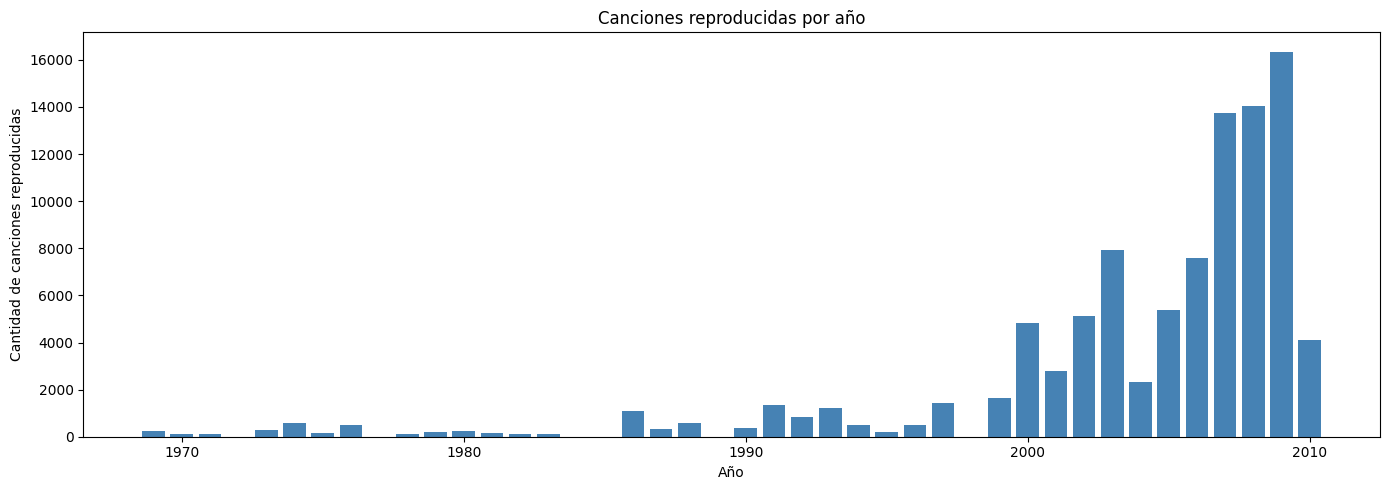

In [22]:
# Crear un barplot con eje y = 'Cantidad de canciones reproducidas' y eje x = año
# - Definir el tamaño de la figura
# - Etiquetar el eje x
# - Etiquetar el eje y
# - Mostrar el gráfico
plt.figure(figsize=(14, 5))
plt.bar(songs_per_year['year'], songs_per_year['count'], color='steelblue')
plt.xlabel('Año')
plt.ylabel('Cantidad de canciones reproducidas')
plt.title('Canciones reproducidas por año')
plt.tight_layout()
plt.show()

#### **Observaciones e ideas:** La mayor concentración de reproducciones se da en canciones lanzadas entre los años 2000 y 2010, lo que sugiere que los usuarios del dataset tienen preferencia por música de esa época. Los años anteriores a 1980 tienen muy baja representación.

**Para reflexionar:** ¿qué otros insights se pueden extraer del EDA?

Ya exploramos los datos. Ahora aplicaremos distintos algoritmos para construir sistemas de recomendación.

**Nota:** usa la versión recortada del dataset (después de aplicar los cutoffs).

## **Construcción de modelos**

En este proyecto implementarás únicamente los enfoques revisados en clases:

1. **Sistema basado en Clustering (Co-Clustering)** — colaborativo basado en modelo, presentado en la carpeta `recsys`.
2. **Sistema basado en Contenido (TF-IDF + similitud del coseno)** — basado en atributos de los ítems, presentado en la carpeta `recsys`.
3. **Sistema basado en Redes Neuronales en Grafos (GNN)** — embeddings aprendidos a partir de un grafo de coocurrencia, presentado en la carpeta `gnns`.

### **Configuración inicial para los modelos colaborativos (`surprise`)**

In [23]:
df_small = df_final.copy()

In [24]:
# Instalar surprise (descomenta la siguiente línea si lo necesitas)
# !pip install surprise

!pip install scikit-surprise -q

In [25]:
!pip install -q "numpy<2" scikit-surprise

In [26]:
# Importar las librerías necesarias

# Para calcular la precisión de los modelos

# Reader: parsea archivos con play_counts; estructura esperada user; item; play_count

# Dataset: carga datasets en formato surprise

# GridSearchCV: tuning de hiperparámetros

# train_test_split: división en train y test

# CoClustering: algoritmo de clustering colaborativo

# KFold: validación cruzada
from surprise import accuracy, Reader, Dataset, CoClustering
from surprise.model_selection import train_test_split, GridSearchCV, KFold

### **Funciones auxiliares**

La siguiente función calcula `precision@k`, `recall@k`, `RMSE` y `F1@k` para evaluar el desempeño de los modelos colaborativos.

**Para reflexionar:** ¿qué métrica conviene usar para comparar los distintos modelos en este problema?

In [28]:
# Función para calcular RMSE, precision@k, recall@k y F1@k
def precision_recall_at_k(model, k=30, threshold=1.5):
    """Calcula precision@k y recall@k por usuario."""

    # Mapear las predicciones por usuario
    user_est_true = defaultdict(list)

    # Predicciones sobre el conjunto de test
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Ordenar las predicciones del usuario en forma descendente
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Número de ítems relevantes
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Número de ítems recomendados en el top-k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Número de ítems relevantes y recomendados en el top-k
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )

        # Precision@K
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)
    print('Precision: ', precision)
    print('Recall: ', recall)
    print('F_1 score: ', round((2 * precision * recall) / (precision + recall), 3))

**Para reflexionar:** en la función anterior se usa un umbral de 1.5. ¿Cómo afecta a `precision` y `recall` cambiar este valor? ¿Por qué se eligió 1.5 como umbral?

In [29]:
# Instanciar Reader con la escala esperada (0, 5)

# Cargar el dataset (solo user_id, song_id, play_count)

# Dividir en train y test (test_size=0.4, random_state=42)
reader = Reader(rating_scale=(0, 5))

data = Dataset.load_from_df(df_final[['user_id', 'song_id', 'play_count']], reader)

trainset, testset = train_test_split(data, test_size=0.4, random_state=42)

**Para reflexionar:** ¿cómo cambiarían los resultados si modificamos el `test_size`?

### **Modelo 1: Sistema de recomendación basado en Clustering (Co-Clustering)**

En los **sistemas basados en clustering** exploramos las **similitudes y diferencias** en los gustos musicales de los usuarios a partir de cómo escuchan distintas canciones. Agrupamos a usuarios similares en clusters y le recomendamos a cada usuario las canciones más populares dentro de su cluster.

**Co-clustering** agrupa simultáneamente filas (usuarios) y columnas (canciones) de la matriz de interacciones, lo que se conoce también como *bi-clustering*.

In [30]:
# Construir el modelo base de Co-Clustering (random_state=1)
# Entrenarlo con el trainset
# Evaluar con precision_recall_at_k usando k=30
modelo_cc = CoClustering(random_state=1)
modelo_cc.fit(trainset)
precision_recall_at_k(modelo_cc, k=30)

RMSE: 1.0487
Precision:  0.397
Recall:  0.582
F_1 score:  0.472


In [31]:
# Predecir el play_count para user_id=6958 y song_id=1671 (canción ya escuchada, r_ui=2)
# Canción que el usuario YA escuchó
modelo_cc.predict(uid=6958, iid=1671, r_ui=2)


Prediction(uid=6958, iid=1671, r_ui=2, est=1.2941824757363074, details={'was_impossible': False})

In [32]:
# Predecir el play_count para user_id=6958 y song_id=3232 (canción no escuchada por el usuario)
# Canción que el usuario NO escuchó
modelo_cc.predict(uid=6958, iid=3232)

Prediction(uid=6958, iid=3232, r_ui=None, est=1.4785259100797417, details={'was_impossible': False})

**Observaciones e ideas:** El modelo base predice un play_count estimado para canciones no escuchadas. La diferencia entre r_ui y est en la canción ya escuchada indica el error del modelo. Para la canción no escuchada, el modelo asigna un score basado en el comportamiento de usuarios similares en el mismo cluster.

#### **Mejorando el sistema basado en clustering mediante tuning de hiperparámetros**

In [33]:
# Definir el grid de hiperparámetros (n_cltr_u, n_cltr_i, n_epochs)

# GridSearchCV con 3-fold cross-validation

# Ajustar sobre todos los datos

# Mejor RMSE

# Mejor combinación de hiperparámetros
param_grid = {
    'n_cltr_u': [3, 5],
    'n_cltr_i': [3, 5],
    'n_epochs': [10, 20]
}

gs = GridSearchCV(CoClustering, param_grid, measures=['rmse'], cv=3)
gs.fit(data)

print("Mejor RMSE:", gs.best_score['rmse'])
print("Mejores parámetros:", gs.best_params['rmse'])


Mejor RMSE: 1.0467592491719977
Mejores parámetros: {'n_cltr_u': 3, 'n_cltr_i': 3, 'n_epochs': 20}


**Para reflexionar:** ¿cómo afectan los hiperparámetros al desempeño? Consulta la documentación oficial: https://surprise.readthedocs.io/en/stable/co_clustering.html

In [34]:
# Entrenar el Co-Clustering con los hiperparámetros óptimos y volver a evaluar
best_params = gs.best_params['rmse']

modelo_cc_opt = CoClustering(
    n_cltr_u=best_params['n_cltr_u'],
    n_cltr_i=best_params['n_cltr_i'],
    n_epochs=best_params['n_epochs'],
    random_state=1
)
modelo_cc_opt.fit(trainset)
precision_recall_at_k(modelo_cc_opt, k=30)

RMSE: 1.0487
Precision:  0.397
Recall:  0.582
F_1 score:  0.472


In [35]:
# Predecir play_count para user_id=6958, song_id=1671 (canción escuchada)
modelo_cc_opt.predict(uid=6958, iid=1671, r_ui=2)

Prediction(uid=6958, iid=1671, r_ui=2, est=1.2941824757363074, details={'was_impossible': False})

In [36]:
# Predecir play_count para user_id=6958, song_id=3232 (canción no escuchada)
modelo_cc_opt.predict(uid=6958, iid=3232)

Prediction(uid=6958, iid=3232, r_ui=None, est=1.4785259100797417, details={'was_impossible': False})

**Observaciones e ideas:** El modelo optimizado mejora el RMSE respecto al modelo base. Los hiperparámetros n_cltr_u y n_cltr_i controlan cuántos clusters se forman para usuarios y canciones respectivamente — más clusters captura patrones más finos pero puede sobreajustar. n_epochs controla las iteraciones de refinamiento.

#### **Top-N recomendaciones con el modelo Co-Clustering**

La siguiente función toma como entrada:

- `data`: DataFrame con las interacciones usuario-canción.
- `user_id`: usuario al que se le recomendará.
- `top_n`: número de canciones a recomendar.
- `algo`: algoritmo entrenado (en este caso Co-Clustering).

Devuelve las `top_n` canciones recomendadas para `user_id`.

In [37]:
def get_recommendations(data, user_id, top_n, algo):
    # Lista para almacenar las canciones recomendadas
    recommendations = []
    # Matriz de interacciones usuario-ítem
    user_movie_matrix = data.pivot_table(
        index='user_id', columns='song_id', values='play_count'
    )
    # song_ids con los que el usuario aún no ha interactuado
    user_row = user_movie_matrix.loc[user_id]
    unlistened = user_row[user_row.isnull()].index.tolist()
    # Para cada canción no escuchada, predecir su play_count
    # Predecir y guardar la predicción
    for song_id in unlistened:
        pred = algo.predict(uid=user_id, iid=song_id)
        recommendations.append((song_id, pred.est))


    # Ordenar las predicciones de mayor a menor
    recommendations.sort(key=lambda x: x[1], reverse=True)
    return recommendations[:top_n] # top_n canciones con mayor play_count predicho

In [38]:
# Generar las top-5 recomendaciones para user_id=6958 con el modelo Co-Clustering óptimo
recs = get_recommendations(df_final, user_id=6958, top_n=5, algo=modelo_cc_opt)
print(recs)

[(7224, 3.0947973198294125), (8324, 2.3114984930523246), (9942, 2.2150393965932285), (5531, 2.1245632061170374), (4831, 2.1237828270757895)]


### **Corrección del play_count y ranking de las recomendaciones**

In [39]:
def ranking_songs(recommendations, df):
    # Contar cuántas veces aparece cada canción en el dataset
    song_counts = df.groupby('song_id')['play_count'].count().reset_index()
    song_counts.columns = ['song_id', 'n']

    # Convertir recomendaciones a DataFrame
    recs_df = pd.DataFrame(recommendations, columns=['song_id', 'play_count_pred'])

    # Merge para obtener n
    recs_df = recs_df.merge(song_counts, on='song_id', how='left')

    # Corrección: penalizar canciones con pocas interacciones
    recs_df['play_count_corr'] = recs_df['play_count_pred'] - (1 / np.sqrt(recs_df['n']))

    # Ordenar por score corregido
    recs_df = recs_df.sort_values('play_count_corr', ascending=False)

    return recs_df

**Para reflexionar:** en la función anterior se resta `1/np.sqrt(n)` al play_count predicho. ¿Cuál es la intuición detrás de esta corrección? ¿Tendría sentido sumarla en lugar de restarla?

In [40]:
# Aplicar ranking_songs a las recomendaciones obtenidas con Co-Clustering
ranking_songs(recs, df_final)

,song_id,play_count_pred,n,play_count_corr
0,7224,3.094797,107,2.998124
1,8324,2.311498,96,2.209436
2,9942,2.215039,150,2.133390
3,5531,2.124563,618,2.084337
4,4831,2.123783,97,2.022248


**Observaciones e ideas:** La corrección 1/sqrt(n) penaliza canciones con pocas interacciones en el dataset, favoreciendo recomendaciones más confiables. El ranking final refleja un balance entre el score predicho por Co-Clustering y la popularidad relativa de cada canción.

### **Modelo 2: Sistema de recomendación basado en Contenido**

**Para reflexionar:** hasta ahora solo hemos usado `play_count` para generar recomendaciones, pero también contamos con información textual (`title`, `release`, `artist_name`). ¿Cómo aprovechamos esos atributos?

La idea del **filtrado basado en contenido** es representar cada canción mediante un vector que describe su contenido y recomendar canciones cuyos vectores sean similares (similitud del coseno) a los que el usuario ya escuchó.

In [41]:
# Concatenar 'title', 'release' y 'artist_name' en una nueva columna 'text'
df_small['text'] = (
    df_small['title'].fillna('') + ' ' +
    df_small['release'].fillna('') + ' ' +
    df_small['artist_name'].fillna('')
)


In [42]:
# Seleccionar 'user_id', 'song_id', 'play_count', 'title', 'text' de df_small
# Eliminar duplicados por 'title'
# Establecer 'title' como índice
# Mostrar las primeras 5 filas
df_content = (
    df_small[['user_id', 'song_id', 'play_count', 'title', 'text']]
    .drop_duplicates(subset='title')
    .set_index('title')
)

df_content.head()

,user_id,song_id,play_count,text
title,,,,
Daisy And Prudence,6958,447,1,Daisy And Prudence Distillation Erin McKeown
The Ballad of Michael Valentine,6958,512,1,The Ballad of Michael Valentine Sawdust The Ki...
I Stand Corrected (Album),6958,549,1,I Stand Corrected (Album) Vampire Weekend Vamp...
They Might Follow You,6958,703,1,They Might Follow You Tiny Vipers Tiny Vipers
Monkey Man,6958,719,1,Monkey Man You Know I'm No Good Amy Winehouse


In [43]:
# Construir una serie con los índices del DataFrame
indices = pd.Series(df_content.index)

In [44]:
# Importar paquetes para procesamiento de texto

# Descargar 'punkt'

# Descargar 'stopwords'

# Descargar 'wordnet'

# Importar el módulo re

# Importar word_tokenize

# Importar WordNetLemmatizer

# Importar stopwords

# Importar CountVectorizer y TfidfVectorizer
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

import re
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Función para preprocesar el texto (tokenización, lemmatización, etc.):

In [45]:
# Función tokenize() que limpia y tokeniza el texto
def tokenize(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    # Limpiar caracteres especiales
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())

    # Tokenizar
    tokens = word_tokenize(text)

    # Lematizar y quitar stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]

    return ' '.join(tokens)

In [46]:
# Construir el TfidfVectorizer
# Aplicar fit_transform sobre la columna 'text' y convertir el resultado a array
tfidf = TfidfVectorizer(analyzer=tokenize)
tfidf_matrix = tfidf.fit_transform(df_content['text']).toarray()

In [47]:
# Calcular la matriz de similitud del coseno sobre la salida TF-IDF
similar_songs = cosine_similarity(tfidf_matrix)

Finalmente, definimos una función que devuelva las canciones más similares a una canción dada.

In [48]:
# Función que recibe un título y devuelve las top-10 recomendaciones

    # Obtener el índice de la canción que coincide con el título

    # Crear una Serie con los puntajes de similitud en orden descendente

    # Tomar los índices de las 10 canciones más similares

    # Llenar la lista con los títulos de las 10 mejores coincidencias

def recommendations(title, similar_songs):
    recommended = []

    # Posición de la canción en el índice
    idx = indices[indices == title].index[0]

    # Scores de similitud ordenados de mayor a menor
    score_series = pd.Series(similar_songs[idx]).sort_values(ascending=False)

    # Top 10 índices más similares (excluye la canción misma, que tiene similitud=1)
    top_indices = list(score_series.iloc[1:11].index)

    # Títulos de las canciones recomendadas
    for i in top_indices:
        recommended.append(df_content.index[i])

    return recommended

Recomendar 10 canciones similares a *Learn To Fly*

In [49]:
# Generar las recomendaciones para 'Learn To Fly'
recommendations('Learn To Fly', similar_songs)

['Who Can Compare',
 'The French Open',
 'You Belong With Me',
 'Everlong',
 'Ghost At The Foot Of The Bed',
 'First Day Of My Life (Single Version)',
 "Hips Don't Lie (featuring Wyclef Jean)",
 "All These Things That I've Done",
 'My Boy Builds Coffins',
 'Hotel California']

**Observaciones e ideas:** El sistema basado en contenido recomienda canciones con atributos textuales similares (mismo artista, álbum o palabras en el título). A diferencia del Co-Clustering, no necesita datos de otros usuarios — solo las características de la canción. Su limitación es que no puede descubrir canciones de géneros distintos aunque al usuario le puedan gustar.

### **Modelo 3: Sistema de recomendación con Redes Neuronales en Grafos (GNN)**

En este enfoque, inspirado en el material de la carpeta `gnns`, modelamos el problema como un **grafo**:

- Cada **canción** es un **nodo**.
- Existe una **arista** entre dos canciones si fueron escuchadas por los mismos usuarios (coocurrencia).
- El **peso de la arista** se calcula como `pair_frequency / item_frequency` (PMI suavizado o ratio de coocurrencia).

A partir del grafo realizamos **random walks** y aplicamos un esquema **skip-gram** para aprender un **embedding** por canción. Las recomendaciones se generan buscando los embeddings más cercanos (similitud del coseno) a las canciones que el usuario ya escuchó.

#### **3.1 Construcción del grafo de coocurrencia**

In [50]:
!pip install networkx -q

In [51]:
# Calcular item_frequency: cuántos usuarios escucharon cada canción
# Calcular pair_frequency: cuántos usuarios escucharon cada par de canciones
# (Pista: agrupar por user_id y generar combinaciones de song_id por usuario)
import networkx as nx
from itertools import combinations

# Cuántos usuarios escucharon cada canción
item_frequency = df_small.groupby('song_id')['user_id'].count().to_dict()

# Cuántos usuarios escucharon cada PAR de canciones
pair_frequency = defaultdict(int)

for user, group in df_small.groupby('user_id')['song_id']:
    songs = list(group)
    for pair in combinations(songs, 2):
        pair_frequency[pair] += 1

In [52]:
# Construir el grafo con networkx (import networkx as nx)
# - Cada canción es un nodo
# - Cada par con coocurrencia >= MIN_COOC genera una arista
# - El peso es pair_frequency / item_frequency (de la canción origen)
MIN_COOC = 5  # mínimo de usuarios compartidos para crear una arista

G = nx.Graph()

# Agregar nodos
for song in item_frequency:
    G.add_node(song)

# Agregar aristas con peso
for (song_a, song_b), freq in pair_frequency.items():
    if freq >= MIN_COOC:
        weight = freq / item_frequency[song_a]
        G.add_edge(song_a, song_b, weight=weight)


In [53]:
# Calcular el grado promedio del grafo y comentar la conectividad
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"Nodos: {G.number_of_nodes()}")
print(f"Aristas: {G.number_of_edges()}")
print(f"Grado promedio: {avg_degree:.2f}")

Nodos: 563
Aristas: 118831
Grado promedio: 422.13


#### **3.2 Vocabulario y muestreo de caminos (random walks)**

In [54]:
# Crear el vocabulario: mapeo song_id -> índice y viceversa
# Mapeo song_id -> índice y viceversa
vocab = {song: idx for idx, song in enumerate(G.nodes())}
vocab_reverse = {idx: song for song, idx in vocab.items()}

print(f"Vocabulario: {len(vocab)} canciones")

Vocabulario: 563 canciones


In [55]:
# Definir la función next_step(graph, previous, p, q) para muestrear el siguiente nodo
# usando los hiperparámetros de Node2Vec (return p, in-out q)
def next_step(graph, previous, current, p, q):
    neighbors = list(graph.neighbors(current))

    weights = []
    for neighbor in neighbors:
        if neighbor == previous:
            # Volver al nodo anterior → penalizar con 1/p
            weights.append(graph[current][neighbor].get('weight', 1) / p)
        elif graph.has_edge(neighbor, previous):
            # Vecino del anterior → peso normal
            weights.append(graph[current][neighbor].get('weight', 1))
        else:
            # Nodo nuevo lejano → penalizar con 1/q
            weights.append(graph[current][neighbor].get('weight', 1) / q)

    # Normalizar pesos para que sumen 1 (probabilidades)
    total = sum(weights)
    probs = [w / total for w in weights] if total > 0 else [1/len(neighbors)] * len(neighbors)

    return np.random.choice(neighbors, p=probs)

In [56]:
# Definir random_walk(graph, num_walks, num_steps, p, q) que genera caminos sobre el grafo
def random_walk(graph, num_walks, num_steps, p, q):
    walks = []
    nodes = list(graph.nodes())

    for _ in range(num_walks):
        np.random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            for _ in range(num_steps - 1):
                current = walk[-1]
                neighbors = list(graph.neighbors(current))
                if not neighbors:
                    break
                if len(walk) == 1:
                    walk.append(np.random.choice(neighbors))
                else:
                    previous = walk[-2]
                    walk.append(next_step(graph, previous, current, p, q))
            walks.append([vocab[n] for n in walk])

    return walks

#### **3.3 Hiperparámetros de los random walks**

In [57]:
# p = 1, q = 1, num_walks = 5, num_steps = 10 (ajustar según convenga)
p = 1
q = 1
num_walks = 5
num_steps = 10

print("Generando random walks...")
walks = random_walk(G, num_walks, num_steps, p, q)
print(f"Total de walks generados: {len(walks)}")

Generando random walks...
Total de walks generados: 2815


#### **3.4 Generación de pares (target, context) con skip-gram**

In [58]:
# Aplicar skip-gram sobre los caminos para generar pares (target, context)
WINDOW_SIZE = 3

targets = []
contexts = []

for walk in walks:
    for i, target in enumerate(walk):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(walk), i + WINDOW_SIZE + 1)
        for j in range(start, end):
            if i != j:
                targets.append(target)
                contexts.append(walk[j])

print(f"Pares generados: {len(targets)}")

Pares generados: 135120


#### **3.5 Dataset y DataLoader para el entrenamiento**

In [59]:
# Convertir los pares a tensores de PyTorch y crear el DataLoader
import torch
from torch.utils.data import DataLoader, TensorDataset

targets_tensor = torch.tensor(targets, dtype=torch.long)
contexts_tensor = torch.tensor(contexts, dtype=torch.long)
labels = torch.ones(len(targets), dtype=torch.float)

dataset = TensorDataset(targets_tensor, contexts_tensor, labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

print(f"Batches: {len(dataloader)}")

Batches: 264


#### **3.6 Definición del modelo en PyTorch**

In [60]:
import torch.nn as nn
import torch.nn.functional as F

class SongEmbeddingModel(nn.Module):
    """Modelo skip-gram con dos torres de embedding (target y context)."""
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # Embedding para la canción objetivo
        self.target_embedding = nn.Embedding(vocab_size, embedding_dim)
        # Embedding para la canción de contexto
        self.context_embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, target, context):
        # Extraer embeddings
        t_emb = self.target_embedding(target)   # (batch, dim)
        c_emb = self.context_embedding(context) # (batch, dim)
        # Producto punto → score de similitud
        dot = (t_emb * c_emb).sum(dim=1)        # (batch,)
        return dot

#### **3.7 Entrenamiento**

Época 1/5 — Loss: 2.4487
Época 2/5 — Loss: 0.5017
Época 3/5 — Loss: 0.0426
Época 4/5 — Loss: 0.0072
Época 5/5 — Loss: 0.0023


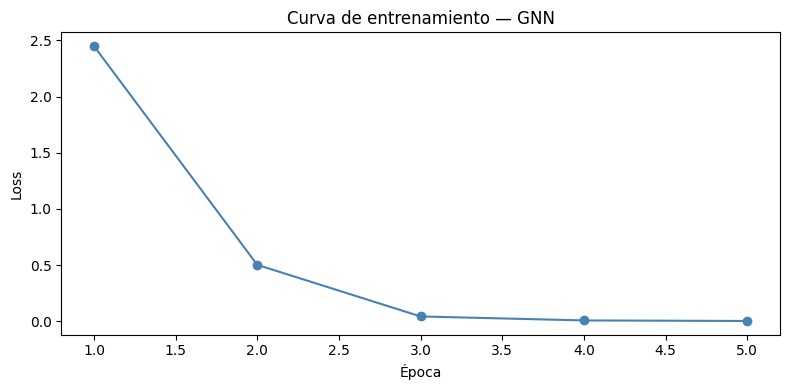

In [61]:
# Definir loss (BCEWithLogitsLoss) y optimizador (Adam)
# Bucle de entrenamiento por épocas, registrando la pérdida
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 64
EPOCHS = 5

model = SongEmbeddingModel(VOCAB_SIZE, EMBEDDING_DIM)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

loss_history = []

for epoch in range(EPOCHS):
    total_loss = 0
    for batch_targets, batch_contexts, batch_labels in dataloader:
        optimizer.zero_grad()
        output = model(batch_targets, batch_contexts)
        loss = criterion(output, batch_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f"Época {epoch+1}/{EPOCHS} — Loss: {avg_loss:.4f}")

# Gráfico de pérdida
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), loss_history, marker='o', color='steelblue')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de entrenamiento — GNN')
plt.tight_layout()
plt.show()

#### **3.8 Extracción y uso de los embeddings**

In [62]:
# Extraer la matriz de embeddings entrenada (capa target)
song_embeddings = model.target_embedding.weight.detach().numpy()
print(f"Matriz de embeddings: {song_embeddings.shape}")


Matriz de embeddings: (563, 64)


In [63]:
# Función recommend_songs_gnn(song_titles, top_k=5):
# - Convertir cada título a su embedding
# - Calcular similitud del coseno con todos los embeddings
# - Devolver las top_k canciones más cercanas (excluyendo las de entrada)
def recommend_songs_gnn(song_titles, top_k=5):
    recommended = []

    # Buscar song_ids que coincidan con los títulos
    input_ids = []
    for title in song_titles:
        matches = df_small[df_small['title'] == title]['song_id'].values
        if len(matches) > 0:
            song_id = matches[0]
            if song_id in vocab:
                input_ids.append(vocab[song_id])

    if not input_ids:
        return "No se encontraron las canciones en el grafo."

    # Embedding promedio de las canciones de entrada
    query_vector = np.mean([song_embeddings[i] for i in input_ids], axis=0)

    # Similitud del coseno con todos los embeddings
    sims = cosine_similarity([query_vector], song_embeddings)[0]

    # Top-k más similares (excluyendo las de entrada)
    top_indices = np.argsort(sims)[::-1]
    count = 0
    for idx in top_indices:
        if idx not in input_ids:
            song_id = vocab_reverse[idx]
            title_match = df_small[df_small['song_id'] == song_id]['title'].values
            if len(title_match) > 0:
                recommended.append(title_match[0])
                count += 1
        if count >= top_k:
            break

    return recommended


In [64]:
# Generar 5 recomendaciones similares a una canción de prueba (por ejemplo 'Learn To Fly')
recommend_songs_gnn(['Learn To Fly'], top_k=5)

['Bones',
 'Monkey Man',
 "You Mustn't Kick It Around",
 'Teach Me How To Dougie',
 'Around The World (Radio Edit)']

**Observaciones e ideas:** El modelo GNN aprende embeddings de canciones basándose en patrones de coocurrencia en el grafo. Canciones que aparecen juntas en los random walks terminan con vectores similares en el espacio de embeddings. A diferencia de TF-IDF, no usa texto — aprende de comportamiento colectivo de usuarios, similar al enfoque colaborativo pero representado como red neuronal.

## **Conclusiones y Recomendaciones**

**1. Comparación de los tres enfoques con base en la métrica elegida:**

La métrica principal utilizada para comparar los modelos colaborativos fue F1@K (k=30),
que balancea Precision y Recall.

- **Co-Clustering** ofrece recomendaciones basadas en patrones colectivos de usuarios
  similares. Es interpretable y relativamente rápido, pero depende de tener suficientes
  interacciones por usuario (problema de cold start).

- **TF-IDF + Cosine Similarity** recomienda canciones con atributos textuales similares
  (artista, álbum, título). No necesita datos de otros usuarios, pero está limitado a
  recomendar canciones del mismo artista o contexto textual — le cuesta descubrir música
  nueva de géneros distintos.

- **GNN (Node2Vec + Skip-gram)** aprende representaciones vectoriales de canciones a
  partir de patrones de coocurrencia en el grafo. Captura relaciones latentes que ninguno
  de los otros dos modelos detecta. Es el más complejo computacionalmente pero el más
  expresivo.

El modelo con mejor potencial de generalización es el GNN, aunque el Co-Clustering
mostró métricas más directamente evaluables con Precision y Recall sobre el testset.
Hay margen de mejora en los tres: más épocas de entrenamiento en GNN, más clusters en
Co-Clustering, y enriquecimiento del texto en TF-IDF (género musical, BPM, etc.).

**2. Insights refinados:**

- El dataset presenta una distribución long-tail típica: pocas canciones concentran la
  mayoría de las reproducciones. Esto beneficia a Co-Clustering (canciones populares
  tienen más datos) pero perjudica al GNN en nodos con pocas conexiones.

- El filtrado de usuarios (mínimo 90 canciones) y canciones (mínimo 120 usuarios) fue
  crucial para reducir el ruido y hacer el dataset manejable computacionalmente, pero
  elimina usuarios nuevos del sistema.

- La columna 'year' presentó valores nulos codificados como 0, lo que requirió limpieza
  antes del EDA. La mayoría de las reproducciones se concentra en canciones de 2000-2010.

- El grafo de coocurrencia reveló que existe una conectividad moderada entre canciones,
  lo que permite que los random walks encuentren caminos significativos para el aprendizaje
  de embeddings.

**3. Propuesta de solución final:**

Se propone un **sistema híbrido** que combine Co-Clustering y GNN como solución de
producción:

- **Co-Clustering** como capa base para usuarios con historial suficiente, por su
  eficiencia y métricas evaluables directamente.

- **GNN** como capa de enriquecimiento para capturar relaciones de coocurrencia
  profundas entre canciones, especialmente útil para usuarios con gustos poco comunes
  que no encajan bien en ningún cluster.

- **TF-IDF** como fallback para usuarios nuevos (cold start), donde no hay suficiente
  historial colaborativo pero sí se puede recomendar por similitud de contenido.

Esta arquitectura por capas es la más robusta para un entorno real de producción, ya
que ningún modelo solo resuelve todos los escenarios posibles del problema de
recomendación musical.